In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Zomato-data-.csv")
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


## Data Cleaning and Preparation
Before moving further we need to clean and process the data

In [3]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0];
    return float(value)

df['rate'] = df['rate'].apply(handleRate)
# print(df.head())
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


## Getting summary of the dataframe 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [5]:
# Checking for missing and null values
print(df.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


In [6]:
# As we can see there is no null value in the dataframe


Text(0.5, 0, 'Type of restaurant')

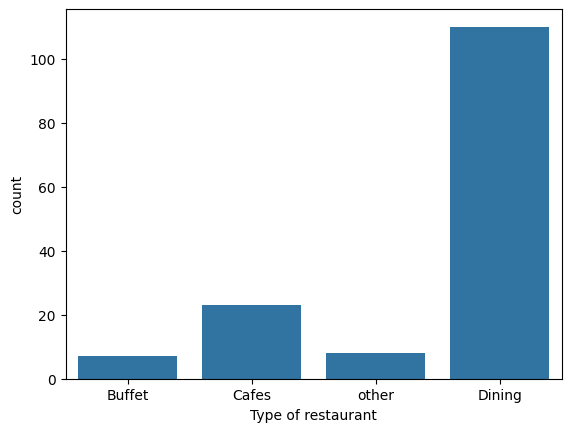

In [7]:
# Exploring the restuarant type
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("Type of restaurant")

Conclusion: The majority of the restaurants fall inot the dining category.

Text(0, 0.5, 'Votes')

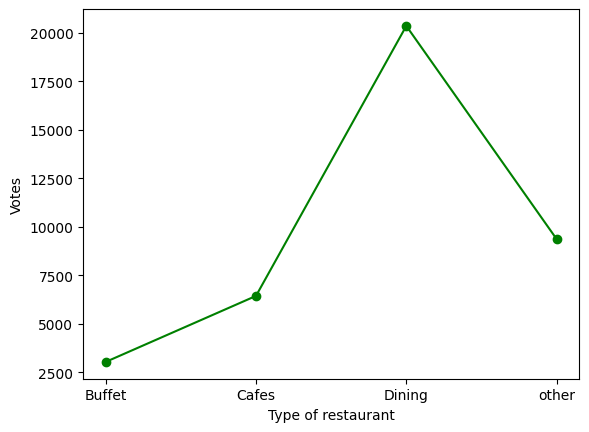

In [8]:
# Votes by Restaurant Type
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes':grouped_data})
plt.plot(result, c='green', marker = 'o')
plt.xlabel("Type of restaurant")
plt.ylabel("Votes")

Conclusio: Dining restaurants are preferred by a large number of individuals.

In [9]:
# Identify the most voted restaurant
max_votes = df['votes'].max()
res_with_max_votes = df.loc[df['votes'] == max_votes, 'name']
print("Restaurant(s) with the maximum votes:")
print(res_with_max_votes)

Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: object


<Axes: xlabel='online_order', ylabel='count'>

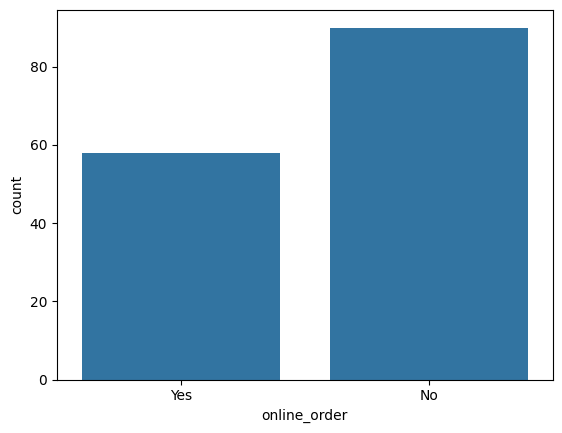

In [10]:
# Online Order availability
sns.countplot(x=df['online_order'])

Conclusion : this suggest that a majority of the restaurant do not accept online orders

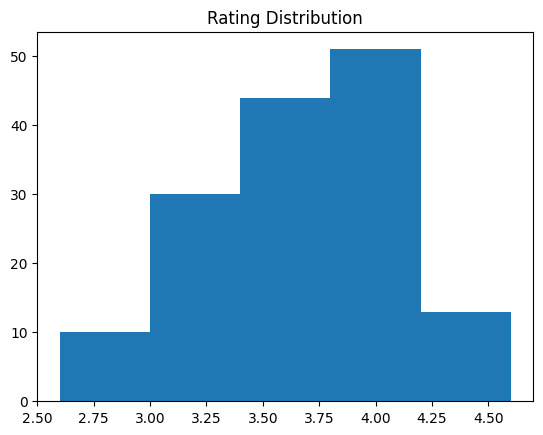

In [11]:
# Analyze ratings
plt.hist(df['rate'], bins=5)
plt.title('Rating Distribution')
plt.show()

Conclusion:- The majority of restaurants recieved ratings from 3.5 to 4

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

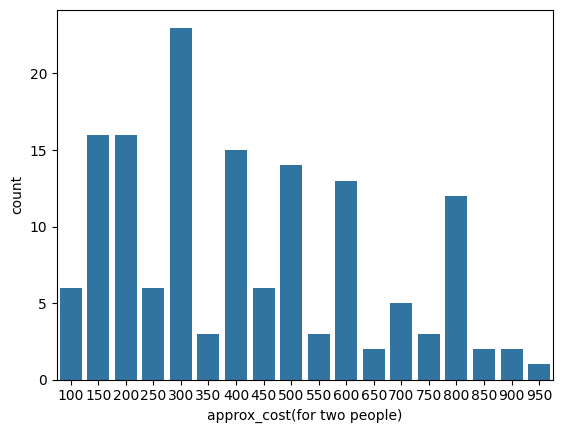

In [12]:
# Approximate cost for couples
couple_data = df['approx_cost(for two people)']
sns.countplot(x=couple_data)

Conclusion:- The majority of couple prefer restaurants with an approximate cost of 300

<Axes: xlabel='online_order', ylabel='rate'>

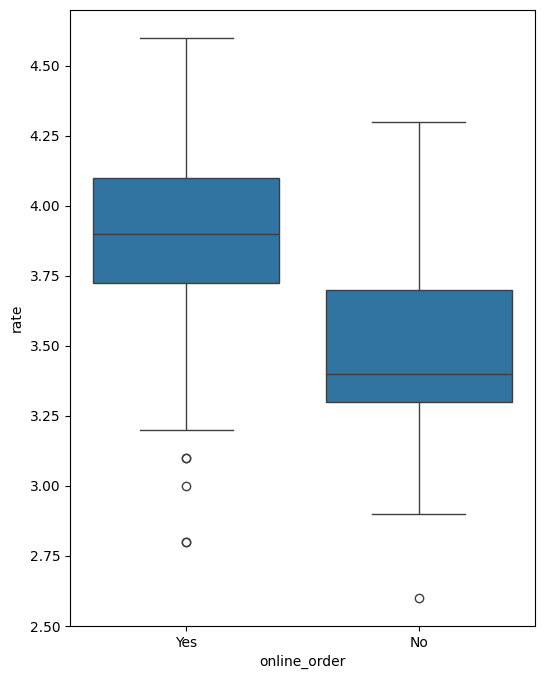

In [13]:
#  Rating Comparison - Online vs Offline Orders

plt.figure(figsize = (6,8))
sns.boxplot(x='online_order', y ='rate',data = df)

Conclusion:- Offline orders recieved lower rating as compared to online rating which obtained excellent rating

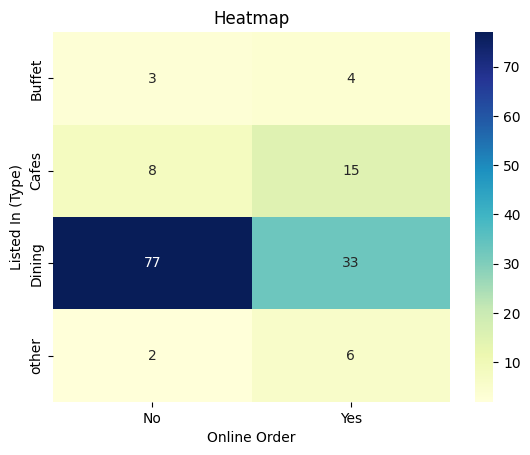

In [14]:
# Order mode preference by Restaurant Type

pivot_table = df.pivot_table(index='listed_in(type)',
                            columns = 'online_order', aggfunc='size',fill_value=0)
sns.heatmap(pivot_table, annot = True, cmap = 'YlGnBu', fmt = 'd')

plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed In (Type)")
plt.show()

Conclusion:- With this we can say that dining restaurants primarily accept
offline orders whereas cafes primarily recieve online orders.
This suggests that clients prefer to place orders in person at restaurants but prefer online ordering at cafes.